# Modeling

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, ElasticNet  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

In [2]:
TRAIN_PATH = Path("../data/processed/train.csv")
VALIDATION_PATH = Path("../data/processed/validation.csv")
TEST_PATH = Path("../data/processed/test.csv")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df["DateTime"] = pd.to_datetime(train_df["DateTime"])
val_df["DateTime"] = pd.to_datetime(val_df["DateTime"])
test_df["DateTime"] = pd.to_datetime(test_df["DateTime"])

In [3]:
feature_columns = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day_of_week", "is_weekend", "elapsed_hours", "elapsed_days",
    "T_RH", "T_AH", "S1_S5_ratio", "S3_S5_diff", "S1_S3_diff"
]

feature_columns_without_nmHC = [column for column in feature_columns if column != "PT08.S2(NMHC)"]

base_columns = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day_of_week", "is_weekend"
]
drift_columns = ["elapsed_hours", "elapsed_days", "T_RH", "T_AH", "S1_S5_ratio", "S3_S5_diff", "S1_S3_diff"]
base_without_nmHC = [c for c in base_columns if c != "PT08.S2(NMHC)"]

target_columns = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

lag_sensors = ["PT08.S1(CO)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
lag_steps = [1, 24]
lag_columns = [
    f"{sensor}_lag{lag}" 
    for sensor in lag_sensors 
    for lag in lag_steps
]

roll_sensors = ["PT08.S5(O3)", "PT08.S1(CO)"]
roll_columns = [f"{s}_roll24" for s in roll_sensors]

features_by_target = {
    "CO(GT)": base_columns,
    "C6H6(GT)": base_columns,
    "NOx(GT)": feature_columns + lag_columns + roll_columns,
    "NO2(GT)": feature_columns_without_nmHC + lag_columns + roll_columns
}

In [4]:
split_lengths = {
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df),
}

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

for sensor in lag_sensors:
    for lag in lag_steps:
        all_df[f"{sensor}_lag{lag}"] = all_df[sensor].shift(lag)

for sensor in roll_sensors:
    all_df[f"{sensor}_roll24"] = all_df[sensor].rolling(24).mean().shift(1) 

causal_probe = pd.Series([10.0, 20.0, 30.0, 40.0])
lag1_probe = causal_probe.shift(1)
roll_probe = causal_probe.rolling(2).mean().shift(1)

In [5]:
all_feature_cols = feature_columns + lag_columns + roll_columns
feature_frame = all_df[["DateTime"] + all_feature_cols].copy()
missing_before_ffill = feature_frame[all_feature_cols].isna().sum()
feature_frame[all_feature_cols] = feature_frame[all_feature_cols].ffill()
missing_after_ffill = feature_frame[all_feature_cols].isna().sum()

display(missing_before_ffill.sort_values(ascending=False).to_frame("before_ffill"))
display(missing_after_ffill.sort_values(ascending=False).to_frame("after_ffill"))

,before_ffill
PT08.S1(CO)_roll24,736
PT08.S5(O3)_roll24,736
PT08.S1(CO)_lag24,390
PT08.S3(NOx)_lag24,390
PT08.S4(NO2)_lag24,390
PT08.S5(O3)_lag24,390
PT08.S3(NOx)_lag1,367
PT08.S1(CO)_lag1,367
PT08.S4(NO2)_lag1,367
PT08.S5(O3)_lag1,367


,after_ffill
PT08.S4(NO2)_lag24,24
PT08.S3(NOx)_lag24,24
PT08.S5(O3)_lag24,24
PT08.S1(CO)_roll24,24
PT08.S1(CO)_lag24,24
PT08.S5(O3)_roll24,24
PT08.S3(NOx)_lag1,1
PT08.S1(CO)_lag1,1
PT08.S4(NO2)_lag1,1
PT08.S5(O3)_lag1,1


In [6]:
for split_name, frame in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}.items():
    valid_rows = frame[["PT08.S2(NMHC)", "C6H6(GT)"]].dropna()
    correlation = valid_rows["PT08.S2(NMHC)"].corr(
        valid_rows["C6H6(GT)"]
    )

    print(
        f"{split_name}: "
        f"rows={len(valid_rows)}, "
        f"correlation={correlation:.6f}"
    )

train: rows=6401, correlation=0.982988
validation: rows=1263, correlation=0.980636
test: rows=1327, correlation=0.982181


In [7]:
train_features = feature_frame.iloc[:split_lengths["train"]].copy().reset_index(drop=True)
validation_features = feature_frame.iloc[
    split_lengths["train"]:split_lengths["train"] + split_lengths["validation"]
].copy().reset_index(drop=True)
test_features = feature_frame.iloc[
    split_lengths["train"] + split_lengths["validation"]:
].copy().reset_index(drop=True)

X_train_filled = train_features[all_feature_cols]
X_validation_filled = validation_features[all_feature_cols]
X_test_filled = test_features[all_feature_cols]

In [9]:
def make_pipeline(estimator, use_scaler=True, scaler="standard"):
    steps = [("median_imputer", SimpleImputer(strategy="median"))]
    if use_scaler:
        scaler_obj = StandardScaler() if scaler == "standard" else RobustScaler()
        steps.append(("scaler", scaler_obj))
    steps.append(("model", estimator))
    return Pipeline(steps)

def make_searches_for_target(target):
    ridge_pipe = make_pipeline(Ridge(), use_scaler=True, scaler="robust")
    rf_pipe = make_pipeline(RandomForestRegressor(random_state=42, n_jobs=-1), use_scaler=False)
    xgb_pipe = make_pipeline(XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        random_state=42, n_jobs=-1
    ), use_scaler=False)
    hgb_pipe = make_pipeline(HistGradientBoostingRegressor(random_state=42), use_scaler=False)
    en_pipe = make_pipeline(ElasticNet(random_state=42), use_scaler=True, scaler="robust")

    if target == "CO(GT)":
        return {
            "RandomForest": (rf_pipe, {
                "model__n_estimators": [300, 500],
                "model__max_depth": [None, 10, 20],
                "model__min_samples_leaf": [1, 2, 5],
                "model__max_features": [1.0, "sqrt"]
            }),
            "XGBoost": (xgb_pipe, {
                "model__n_estimators": [200, 300, 500],
                "model__learning_rate": [0.02, 0.03, 0.05],
                "model__max_depth": [2, 3, 4],
                "model__min_child_weight": [1, 3, 5],
                "model__subsample": [0.8, 0.9, 1.0],
                "model__colsample_bytree": [0.8, 0.9, 1.0],
                "model__reg_alpha": [0, 0.1],
                "model__reg_lambda": [1, 5, 10]
            }),
        }
    if target == "NOx(GT)":
        return {
            "Ridge": (ridge_pipe, {"model__alpha": [0.1, 1.0, 10.0, 100.0, 1000.0]}),
            "ElasticNet": (en_pipe, {
                "model__alpha": [0.01, 0.1, 1.0],
                "model__l1_ratio": [0.1, 0.5, 0.9]
            }),
            "XGBoost": (xgb_pipe, {
                "model__n_estimators": [200, 300, 500, 700],
                "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
                "model__max_depth": [2, 3, 4, 5],
                "model__min_child_weight": [1, 3, 5, 10],
                "model__subsample": [0.7, 0.8, 0.9],
                "model__colsample_bytree": [0.7, 0.8, 0.9],
                "model__reg_alpha": [0, 0.01, 0.1, 1],
                "model__reg_lambda": [1, 5, 10, 20]
            }),
            "HistGradientBoosting": (hgb_pipe, {
                "model__max_iter": [200, 300, 500],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [3, 5, None],
                "model__l2_regularization": [0, 1, 10]
            }),
        }
    return {
        "RandomForest": (rf_pipe, {
            "model__n_estimators": [300, 500],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 2, 5],
            "model__max_features": [1.0, "sqrt"]
        }),
        "XGBoost": (xgb_pipe, {
            "model__n_estimators": [200, 300, 500, 700],
            "model__learning_rate": [0.01, 0.02, 0.03, 0.05],
            "model__max_depth": [2, 3, 4, 5],
            "model__min_child_weight": [3, 5, 10],
            "model__subsample": [0.7, 0.8, 0.9],
            "model__colsample_bytree": [0.7, 0.8, 0.9],
            "model__reg_alpha": [0, 0.01, 0.1, 1],
            "model__reg_lambda": [1, 5, 10, 20]
        }),
        "HistGradientBoosting": (hgb_pipe, {
            "model__max_iter": [200, 300, 500],
            "model__learning_rate": [0.02, 0.03, 0.05],
            "model__max_depth": [3, 5, None],
            "model__l2_regularization": [0, 1, 10]
        }),
    }

def regression_metrics(y_true, y_pred):
    return {
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

N_ITER_BY_TARGET_MODEL = {
    ("CO(GT)", "XGBoost"): 20,
    ("CO(GT)", "RandomForest"): 12,
    ("NOx(GT)", "XGBoost"): 24,
    ("NOx(GT)", "HistGradientBoosting"): 16,
    ("NO2(GT)", "XGBoost"): 30,
    ("NO2(GT)", "HistGradientBoosting"): 20,
    ("NO2(GT)", "RandomForest"): 16,
}
DEFAULT_N_ITER = 12

In [10]:
cv = TimeSeriesSplit(n_splits=4)
primary_scoring = "neg_root_mean_squared_error"

In [11]:
validation_results = []
best_models = {}
validation_predictions = {}

def valid_target_data(features, frame, target, selected_features):
    mask = frame[target].notna()
    X = features.loc[mask, selected_features].copy()
    y = frame.loc[mask, target].copy()
    return X, y

In [13]:
for target in target_columns:
    selected_features = features_by_target[target]
    X_train, y_train = valid_target_data(X_train_filled, train_df, target, selected_features)
    X_validation, y_validation = valid_target_data(X_validation_filled, val_df, target, selected_features)

    for model_name, (pipeline, parameter_space) in make_searches_for_target(target).items():
        search_class = GridSearchCV if model_name == "Ridge" else RandomizedSearchCV
        search_kwargs = {
            "estimator": pipeline,
            "scoring": primary_scoring,
            "cv": cv,
            "refit": True,
            "n_jobs": 1,
            "error_score": "raise"
        }
        if model_name == "Ridge":
            search_kwargs["param_grid"] = parameter_space
        else:
            search_kwargs["param_distributions"] = parameter_space
            search_kwargs.update({
                "n_iter": N_ITER_BY_TARGET_MODEL.get((target, model_name), DEFAULT_N_ITER), 
                "random_state": 42
            })

        search = search_class(**search_kwargs)
        search.fit(X_train, y_train)
        validation_pred = search.predict(X_validation)
        metrics = regression_metrics(y_validation, validation_pred)

        validation_results.append({
            "target": target,
            "model": model_name,
            "cv_rmse": -search.best_score_,
            "validation_rmse": metrics["rmse"],
            "validation_mae": metrics["mae"],
            "validation_r2": metrics["r2"],
            "best_params": search.best_params_,
        })
        best_models[(target, model_name)] = search
        validation_predictions[(target, model_name)] = (y_validation.copy(), validation_pred)

d:\Ameng\Data Science Project\air-quality-prediction\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 9 is smaller than n_iter=12. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
d:\Ameng\Data Science Project\air-quality-prediction\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.790874e+04, tolerance: 6.626e+02
  model = cd_fast.enet_coordinate_descent(
d:\Ameng\Data Science Project\air-quality-prediction\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.032671e+04, tolerance: 1.24

In [14]:
validation_results_df = pd.DataFrame(validation_results)
best_rows = (
    validation_results_df
    .sort_values(["target", "validation_r2", "validation_rmse"], ascending=[True, False, True])
    .groupby("target", as_index=False)
    .first()
)
display(best_rows.drop(columns=["best_params"]))

selected_models = {
    row.target: best_models[(row.target, row.model)]
    for row in best_rows.itertuples()
}

,target,model,cv_rmse,validation_rmse,validation_mae,validation_r2
0,C6H6(GT),RandomForest,0.294327,0.080646,0.014918,0.999871
1,CO(GT),Ridge,0.488962,0.888282,0.593236,0.696979
2,NO2(GT),Ridge,23.537064,26.336924,19.278641,0.688142
3,NOx(GT),HistGradientBoosting,89.184643,124.098044,73.003068,0.757336


In [15]:
final_results = []
final_predictions = {}

for target in target_columns:
    train_mask = train_df[target].notna()
    validation_mask = val_df[target].notna()
    test_mask = test_df[target].notna()
    selected_features = features_by_target[target]

    X_train_valid = pd.concat([
        X_train_filled.loc[train_mask, selected_features],
        X_validation_filled.loc[validation_mask, selected_features],
    ], ignore_index=True)
    y_train_valid = pd.concat([
        train_df.loc[train_mask, target],
        val_df.loc[validation_mask, target],
    ], ignore_index=True)
    X_test_target = X_test_filled.loc[
        test_mask,
        selected_features,
    ].reset_index(drop=True)
    y_test_target = test_df.loc[test_mask, target].reset_index(drop=True)

    selected_row = best_rows.loc[best_rows["target"] == target].iloc[0]
    selected_model_name = selected_row["model"]
    selected_search = selected_models[target]

    final_pipeline = clone(selected_search.best_estimator_)
    final_pipeline.fit(X_train_valid, y_train_valid)
    test_pred = final_pipeline.predict(X_test_target)
    metrics = regression_metrics(y_test_target, test_pred)
    final_results.append(
        {
            "target": target,
            "best_model": selected_model_name,
            "test_rmse": metrics["rmse"],
            "test_mae": metrics["mae"],
            "test_r2": metrics["r2"],
            "test_rows": len(y_test_target),
        }
    )
    final_predictions[target] = (y_test_target.copy(), test_pred)

final_results_df = pd.DataFrame(final_results)
final_results_df

,target,best_model,test_rmse,test_mae,test_r2,test_rows
0,CO(GT),Ridge,0.868804,0.567017,0.563875,1374
1,C6H6(GT),RandomForest,0.025228,0.011047,0.999983,1327
2,NOx(GT),HistGradientBoosting,99.309412,50.061672,0.721364,1367
3,NO2(GT),Ridge,33.362212,22.030027,0.597031,1367


In [16]:
for target in ["CO(GT)", "NOx(GT)", "NO2(GT)"]:
    sel = features_by_target[target]
    Xtr, ytr = valid_target_data(X_train_filled, train_df, target, sel)
    model = selected_models[target]
    r = permutation_importance(model, Xtr, ytr, n_repeats=10, random_state=42, scoring="neg_root_mean_squared_error")
    imp = pd.Series(r.importances_mean, index=sel).sort_values(ascending=False)
    print(f"\n{target} top10 permutation importance (higher = more important)")
    display(imp.head(10).to_frame("importance"))


CO(GT) top10 permutation importance (higher = more important)


,importance
PT08.S2(NMHC),0.522294
PT08.S4(NO2),0.370285
PT08.S1(CO),0.210838
month_sin,0.135757
AH,0.106008
hour_sin,0.058217
T,0.048272
PT08.S3(NOx),0.037003
PT08.S5(O3),0.032669
is_weekend,0.004321



NOx(GT) top10 permutation importance (higher = more important)


,importance
elapsed_hours,97.616572
PT08.S2(NMHC),75.871009
PT08.S5(O3),23.714224
S3_S5_diff,10.747667
PT08.S3(NOx),8.445409
hour_cos,7.296807
RH,6.132994
T,5.393914
T_AH,3.685398
PT08.S1(CO),3.612726



NO2(GT) top10 permutation importance (higher = more important)


,importance
T_RH,10.446606
PT08.S5(O3)_lag24,4.459312
hour_sin,4.373390
PT08.S1(CO),3.059995
S1_S5_ratio,3.018264
T_AH,2.715894
PT08.S5(O3),2.286977
is_weekend,1.659404
T,1.571302
PT08.S4(NO2)_lag1,1.515442


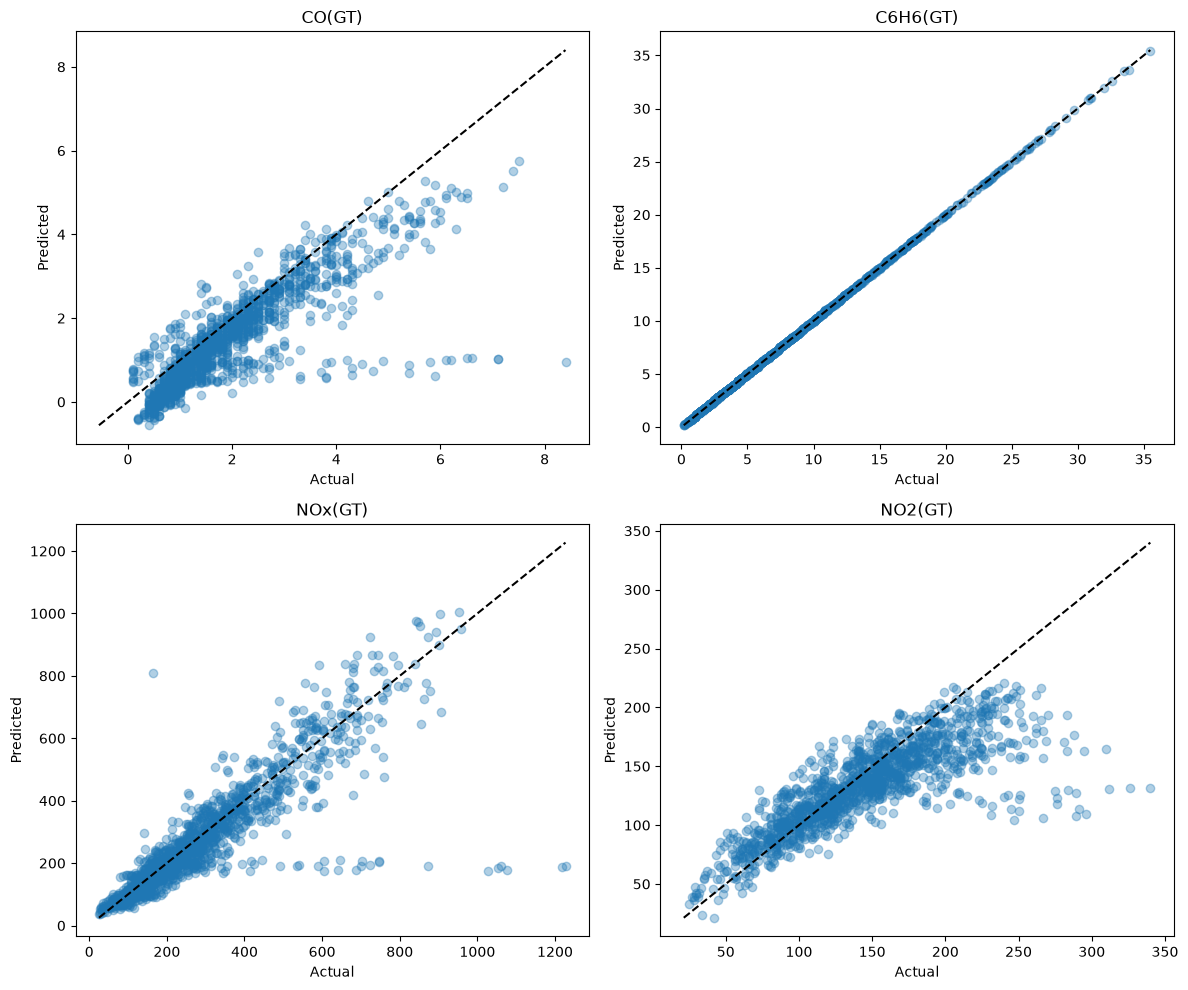

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for axis, target in zip(axes.ravel(), target_columns):
    y_true, y_pred = final_predictions[target]
    axis.scatter(y_true, y_pred, alpha=0.35)
    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())
    axis.plot([lower, upper], [lower, upper], linestyle="--", color="black")
    axis.set_title(target)
    axis.set_xlabel("Actual")
    axis.set_ylabel("Predicted")
plt.tight_layout()